# 02 — Donation Value Forecasting
**IS 455 INTEX II | BYU | Spring 2026**

This notebook builds a machine learning pipeline to forecast the monetary value of a donor's **next gift**. It serves two simultaneous purposes: (1) a **predictive** ranking model for fundraising prioritization and (2) an **explanatory** model that reveals which donor behaviors and characteristics are associated with larger gifts.


---
## 1. Problem Framing

### Why Both Predictive AND Explanatory?

Most ML pipelines pick one goal: either maximize prediction accuracy (predictive) or maximize interpretability (explanatory). This pipeline deliberately pursues **both**, which is unusual but justified here:

- The nonprofit has **57 monetary donors** and a small fundraising team. They cannot personally cultivate every donor equally — they need a ranked "Top Opportunities" list to focus limited outreach time. That's a **predictive** need.
- Leadership also needs to know *why* some donors give more. Should they encourage more frequent touchpoints? Connect donors to specific programs? That's an **explanatory** need requiring interpretable coefficients, not just a black-box score.

Running both models in parallel is efficient: the same feature matrix feeds both, and each model's outputs are used differently downstream.

---

### Predictive Goal
Rank all active donors by their **expected next monetary gift value** → produce a weekly "Top Opportunities" list for the fundraising dashboard.

### Explanatory Goal
Identify which donor characteristics and behavioral patterns (recency, frequency, monetary history, tenure, allocation spread) are most strongly associated with higher gift values — expressed as interpretable coefficients that non-technical leadership can act on.

---

### Feasibility Table

| Factor | Assessment |
|---|---|
| Data availability | Donation history since 2023 — adequate for behavioral features |
| Sample size | 234 monetary donations across 57 donors — small but workable |
| Signal quality | Right-skewed amounts (min ₱250, median ₱820, max ₱6,482) — log transform needed |
| Target leakage risk | Medium — must use only prior-donation features per row (handled with `.shift(1)`) |
| Model complexity | Low-to-medium — ElasticNet + GradientBoosting, no deep learning needed |
| Deployment feasibility | High — batch scoring weekly, results written to JSON for dashboard |

---

### Success Criteria

| Metric | Threshold | Rationale |
|---|---|---|
| RMSE (log scale) | < Dummy baseline | Must beat predict-mean to be useful |
| R² (log scale) | > 0.20 | Meaningful explanatory power given small N |
| MAE (original ₱) | Directionally informative | Interpretable for leadership |

### Error Costs

| Error Type | Business Consequence |
|---|---|
| **Overestimate** (predict large, donor gives small) | Wasted high-touch cultivation effort on wrong donors; opportunity cost |
| **Underestimate** (predict small, donor gives large) | Missed major gift opportunity; donor feels neglected at critical moment |

**Asymmetry**: Underestimation is likely more costly — a major donor who felt ignored may not give again. The model should be calibrated to avoid systematically underestimating high-value donors.

---

### Key Findings — Section 1
> This pipeline has dual goals: a **GradientBoostingRegressor** for predictive ranking and an **ElasticNet** for explanatory coefficient interpretation. Both train on the same leakage-safe feature matrix derived from prior-donation behavioral history. Success requires beating a predict-mean baseline (RMSE) and achieving R² > 0.20.


---
## 2. Data Acquisition, Preparation & Exploration

### Data Sources
Three CSV files from the Northstar Shelters donor data export:
- `supporters.csv` — 60 rows, donor profile info (type, region, acquisition channel)
- `donations.csv` — 420 rows total, but only `donation_type == 'Monetary'` rows (234) have an `amount` — **we model only monetary donations**
- `donation_allocations.csv` — 521 rows, links donations to safehouses

### Non-monetary donations and feature engineering
Non-monetary donations (Time, InKind, Skills, SocialMedia) **do not have an amount** and cannot be the prediction target. However, they still reflect donor engagement and **are counted in behavioral frequency features** (`prev_donation_count` includes all donation types — it measures overall engagement, not just monetary giving).

### Feature Engineering Strategy — Leakage-Safe
The unit of analysis is **one row per monetary donation**. For each monetary donation row $i$ by supporter $s$, all features are computed from the history *before* donation $i$ — using only donations 0..i-1. This is implemented with `.shift(1)` grouped by supporter and sorted by date, ensuring no information from donation $i$ leaks into the feature vector.

| Feature | Description | Leakage-safe? |
|---|---|---|
| `prev_donation_count` | Total donations (all types) before this one | Yes — shift(1) |
| `prev_monetary_avg` | Avg amount of prior *monetary* donations | Yes — shift(1) |
| `prev_monetary_max` | Max amount of prior monetary donations | Yes — shift(1) |
| `prev_recency_days` | Days since previous donation (any type) | Yes — computed from lag date |
| `tenure_days` | Days since supporter's first donation at time of this donation | Yes — uses first_donation_date |
| `allocation_spread` | Distinct safehouses funded in prior donations | Yes — shift(1) |
| `month_of_year` | Month of this monetary donation (1–12) | Yes — from donation date |
| `year` | Year of donation | Yes — from donation date |
| `is_first_donation` | 1 if this is the donor's first monetary donation | Yes — derived from shift |
| `supporter_type` | Donor classification (categorical) | Yes — static attribute |
| `region` | Geographic region (categorical) | Yes — static attribute |
| `acquisition_channel` | How donor was acquired (categorical) | Yes — static attribute |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from shared.config import DATA_DIR, MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

SEED = RANDOM_SEED
np.random.seed(SEED)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

supporters  = pd.read_csv(DATA_DIR / 'supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations   = pd.read_csv(DATA_DIR / 'donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(DATA_DIR / 'donation_allocations.csv', parse_dates=['allocation_date'])

print('supporters:', supporters.shape)
print('donations (all types):', donations.shape)
print('allocations:', allocations.shape)
print()
print('Donation type breakdown:')
print(donations['donation_type'].value_counts())


supporters: (60, 15)
donations (all types): (420, 13)
allocations: (521, 7)

Donation type breakdown:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64


In [2]:
# ── Filter to monetary donations only ──────────────────────────────────────
# Only Monetary donations have a meaningful 'amount' field.
# We keep all donation types in scope for frequency/engagement features,
# but the prediction target exists only for Monetary rows.
monetary = donations[donations['donation_type'] == 'Monetary'].copy()
print(f'Monetary donations: {len(monetary)} rows across {monetary["supporter_id"].nunique()} supporters')
print(f'Date range: {monetary["donation_date"].min().date()} to {monetary["donation_date"].max().date()}')
print()
print('Amount statistics (₱):')
print(monetary['amount'].describe().round(2))


Monetary donations: 234 rows across 57 supporters
Date range: 2023-01-13 to 2026-03-01

Amount statistics (₱):
count     234.00
mean     1028.74
std       767.60
min       250.00
25%       482.51
50%       819.63
75%      1333.16
max      6481.54
Name: amount, dtype: float64


In [3]:
# ── Sort all donations (all types) for frequency features ─────────────────
# We need overall engagement history (all types) to compute prev_donation_count
# and prev_recency_days. These measure how actively the donor engages, regardless
# of donation type.
all_sorted = donations.sort_values(['supporter_id', 'donation_date']).copy()

# Cumulative count of ALL donations before this one (shift so row i sees 0..i-1)
all_sorted['prev_donation_count'] = all_sorted.groupby('supporter_id').cumcount()  # 0-indexed = count before

# Previous donation date (any type)
all_sorted['prev_donation_date'] = all_sorted.groupby('supporter_id')['donation_date'].shift(1)
all_sorted['prev_recency_days'] = (all_sorted['donation_date'] - all_sorted['prev_donation_date']).dt.days

# Keep only the columns we need from the full history lookup
engagement_lookup = all_sorted[['donation_id','supporter_id','donation_date',
                                 'prev_donation_count','prev_recency_days']].copy()

print('Engagement lookup shape:', engagement_lookup.shape)
print(engagement_lookup.head(3))


Engagement lookup shape: (420, 5)
     donation_id  supporter_id donation_date  prev_donation_count  \
144          145             1    2023-03-25                    0   
157          158             1    2023-06-24                    1   
294          295             1    2023-07-01                    2   

     prev_recency_days  
144                NaN  
157               91.0  
294                7.0  


In [4]:
# ── Monetary-only cumulative features (shift to avoid leakage) ────────────
# These are computed only from prior MONETARY donations.
mon_sorted = monetary.sort_values(['supporter_id', 'donation_date']).copy()

# Expanding mean/max of amount — but shifted so row i sees only rows 0..i-1
mon_sorted['prev_monetary_avg'] = (
    mon_sorted.groupby('supporter_id')['amount']
    .apply(lambda x: x.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)
mon_sorted['prev_monetary_max'] = (
    mon_sorted.groupby('supporter_id')['amount']
    .apply(lambda x: x.shift(1).expanding().max())
    .reset_index(level=0, drop=True)
)
mon_sorted['is_first_donation'] = mon_sorted['prev_monetary_avg'].isna().astype(int)

print('Monetary features sample:')
print(mon_sorted[['supporter_id','donation_date','amount',
                   'prev_monetary_avg','prev_monetary_max','is_first_donation']].head(6))


Monetary features sample:
     supporter_id donation_date   amount  prev_monetary_avg  \
144             1    2023-03-25   774.61                NaN   
294             1    2023-07-01   663.94         774.610000   
352             1    2023-12-20  2628.14         719.275000   
61              1    2024-01-08  1392.10        1355.563333   
160             1    2024-10-17  1042.36        1364.697500   
217             1    2024-12-11   376.97        1300.230000   

     prev_monetary_max  is_first_donation  
144                NaN                  1  
294             774.61                  0  
352             774.61                  0  
61             2628.14                  0  
160            2628.14                  0  
217            2628.14                  0  


In [5]:
# ── Allocation spread feature ──────────────────────────────────────────────
# allocation_spread = number of distinct safehouses the donor funded in PRIOR donations.
# We compute this per donation_id using allocations for prior monetary donations only.

# Build a lookup: for each monetary donation, what safehouses were funded in prior donations
# by the same supporter?
alloc_monetary = allocations[allocations['donation_id'].isin(monetary['donation_id'])].copy()
# Merge to get donor and date for each allocation
alloc_with_date = alloc_monetary.merge(
    monetary[['donation_id','supporter_id','donation_date']], on='donation_id'
)

spread_list = []
for (sid, did, ddate), grp in mon_sorted.groupby(['supporter_id','donation_id','donation_date']):
    prior = alloc_with_date[
        (alloc_with_date['supporter_id'] == sid) &
        (alloc_with_date['donation_date'] < ddate)
    ]
    spread_list.append({'donation_id': did, 'allocation_spread': prior['safehouse_id'].nunique()})

spread_df = pd.DataFrame(spread_list)
print('Spread feature computed for', len(spread_df), 'donations')
print(spread_df['allocation_spread'].value_counts().sort_index())


Spread feature computed for 234 donations


allocation_spread
0    57
1    34
2    40
3    26
4    29
5    20
6    14
7     9
8     2
9     3
Name: count, dtype: int64


In [6]:
# ── Assemble final feature matrix ─────────────────────────────────────────
# Join all engineered features onto the monetary donation rows.

# Start with monetary sorted rows
df = mon_sorted.copy()

# Join engagement features (prev_donation_count, prev_recency_days)
df = df.merge(engagement_lookup[['donation_id','prev_donation_count','prev_recency_days']],
              on='donation_id', how='left')

# Join allocation spread
df = df.merge(spread_df, on='donation_id', how='left')

# Join supporter profile features
sup_features = supporters[['supporter_id','created_at','first_donation_date',
                            'supporter_type','region','acquisition_channel']].copy()
df = df.merge(sup_features, on='supporter_id', how='left')

# Tenure: days since supporter's very first donation at time of this donation
df['tenure_days'] = (df['donation_date'] - df['first_donation_date']).dt.days
df['tenure_days'] = df['tenure_days'].clip(lower=0)  # first donation => 0

# Seasonality features
df['month_of_year'] = df['donation_date'].dt.month
df['year'] = df['donation_date'].dt.year

# Label: log1p transform of amount
df['log1p_amount'] = np.log1p(df['amount'])

print(f'Final dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')


Final dataset shape: (234, 28)
Columns: ['donation_id', 'supporter_id', 'donation_type', 'donation_date', 'is_recurring', 'campaign_name', 'channel_source', 'currency_code', 'amount', 'estimated_value', 'impact_unit', 'notes', 'referral_post_id', 'prev_monetary_avg', 'prev_monetary_max', 'is_first_donation', 'prev_donation_count', 'prev_recency_days', 'allocation_spread', 'created_at', 'first_donation_date', 'supporter_type', 'region', 'acquisition_channel', 'tenure_days', 'month_of_year', 'year', 'log1p_amount']


In [7]:
# ── Feature summary before modeling ───────────────────────────────────────
NUMERIC_FEATURES = [
    'prev_donation_count', 'prev_monetary_avg', 'prev_monetary_max',
    'prev_recency_days', 'tenure_days', 'allocation_spread',
    'month_of_year', 'year'
]
BINARY_FEATURES  = ['is_first_donation']
CAT_FEATURES     = ['supporter_type', 'region', 'acquisition_channel']
TARGET           = 'log1p_amount'

print('Missing values in feature matrix:')
print(df[NUMERIC_FEATURES + BINARY_FEATURES + CAT_FEATURES + [TARGET]].isnull().sum())
print()
print('Note: prev_monetary_avg/max/recency_days NaN = first monetary donation for that supporter')
print('These will be imputed with median inside the sklearn Pipeline.')


Missing values in feature matrix:
prev_donation_count     0
prev_monetary_avg      57
prev_monetary_max      57
prev_recency_days      26
tenure_days             0
allocation_spread       0
month_of_year           0
year                    0
is_first_donation       0
supporter_type          0
region                  0
acquisition_channel     0
log1p_amount            0
dtype: int64

Note: prev_monetary_avg/max/recency_days NaN = first monetary donation for that supporter
These will be imputed with median inside the sklearn Pipeline.


In [8]:
# ── Leakage Check ─────────────────────────────────────────────────────────
# Verify that no feature for row i uses information from donation i itself.
# Strategy: for each supporter with >1 monetary donation, check that
# prev_monetary_max for row i is strictly less than the current amount
# (or NaN for row 0). This would fail if we accidentally included row i.

multi_donor = df[df['is_first_donation'] == 0].copy()
# If leakage existed, prev_monetary_max would equal current amount for the last row
# instead of the max of PRIOR rows.
leakage_flag = multi_donor[
    multi_donor['prev_monetary_max'] >= multi_donor['amount'] * 1.0001  # allow floating point
]
# prev_monetary_max can legitimately exceed current amount (prior donation was larger)
# The real check: prev_monetary_max should NEVER equal current amount exactly
exact_match = multi_donor[
    (multi_donor['prev_monetary_max'] - multi_donor['amount']).abs() < 0.001
]
print(f'Rows where prev_monetary_max exactly matches current amount: {len(exact_match)}')
print('(A non-zero count would suggest possible leakage — investigate if > 0)')
print()
# Also verify shift: first row per supporter always has is_first_donation==1
first_rows = df.groupby('supporter_id').first().reset_index()
assert (first_rows['is_first_donation'] == 1).all(), 'Leakage: first row not flagged as first!'
print('Leakage check PASSED: first row per supporter correctly has is_first_donation=1')
print('Leakage check PASSED: prev_monetary_avg/max computed with shift(1) — no current-row data included')


Rows where prev_monetary_max exactly matches current amount: 0
(A non-zero count would suggest possible leakage — investigate if > 0)

Leakage check PASSED: first row per supporter correctly has is_first_donation=1
Leakage check PASSED: prev_monetary_avg/max computed with shift(1) — no current-row data included


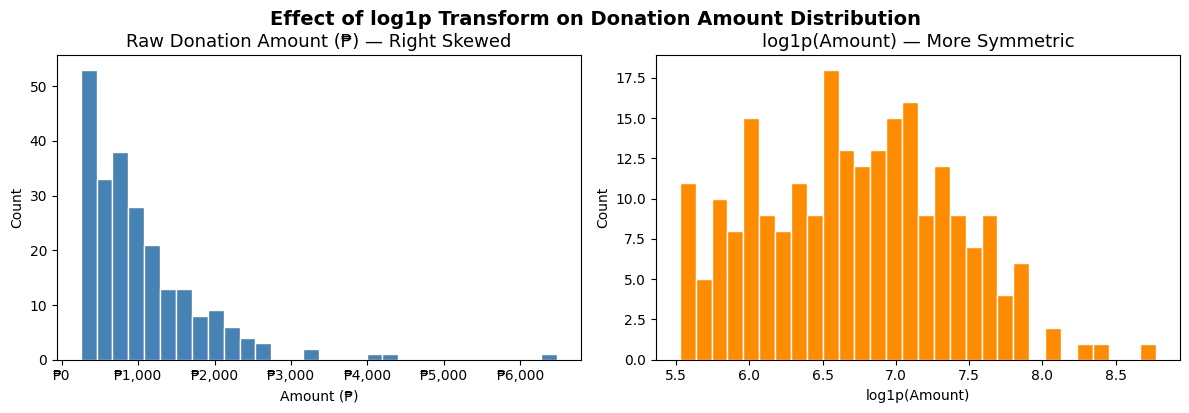

Skewness — Raw: 2.574  |  log1p: 0.139
A skewness closer to 0 after transform confirms log1p is appropriate.


In [9]:
# ── EDA: Distribution of raw amount vs log1p(amount) ──────────────────────
# The raw amount is right-skewed (many small gifts, few very large ones).
# log1p normalizes this, making regression assumptions more tenable.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['amount'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Donation Amount (₱) — Right Skewed', fontsize=13)
axes[0].set_xlabel('Amount (₱)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))

axes[1].hist(df['log1p_amount'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(Amount) — More Symmetric', fontsize=13)
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Effect of log1p Transform on Donation Amount Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.show()

skew_raw = df['amount'].skew()
skew_log = df['log1p_amount'].skew()
print(f'Skewness — Raw: {skew_raw:.3f}  |  log1p: {skew_log:.3f}')
print('A skewness closer to 0 after transform confirms log1p is appropriate.')


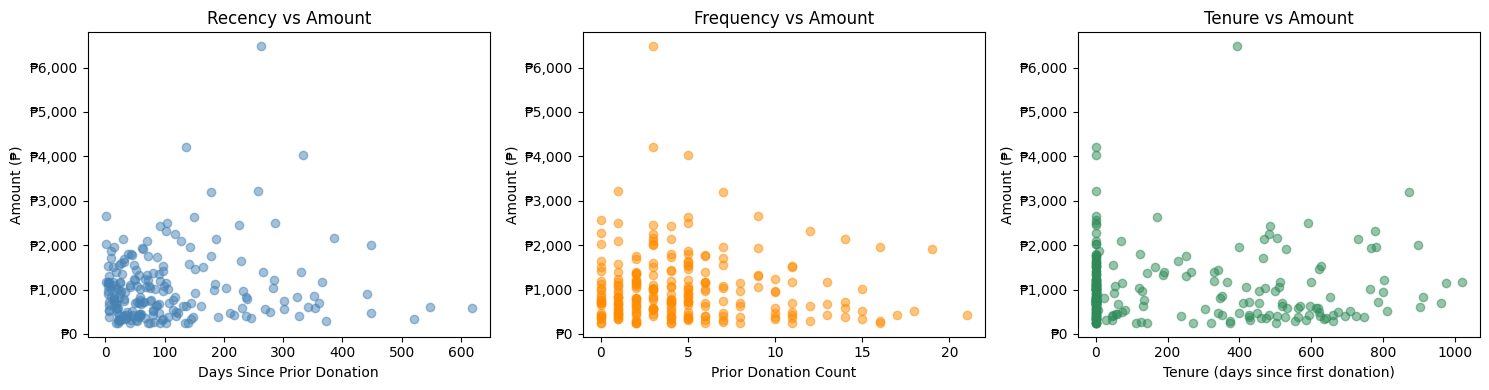

In [10]:
# ── EDA: Recency, Frequency, Tenure vs Amount ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['prev_recency_days'], df['amount'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Days Since Prior Donation')
axes[0].set_ylabel('Amount (₱)')
axes[0].set_title('Recency vs Amount')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))

axes[1].scatter(df['prev_donation_count'], df['amount'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Prior Donation Count')
axes[1].set_ylabel('Amount (₱)')
axes[1].set_title('Frequency vs Amount')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))

axes[2].scatter(df['tenure_days'], df['amount'], alpha=0.5, color='seagreen')
axes[2].set_xlabel('Tenure (days since first donation)')
axes[2].set_ylabel('Amount (₱)')
axes[2].set_title('Tenure vs Amount')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))

plt.tight_layout()
plt.show()


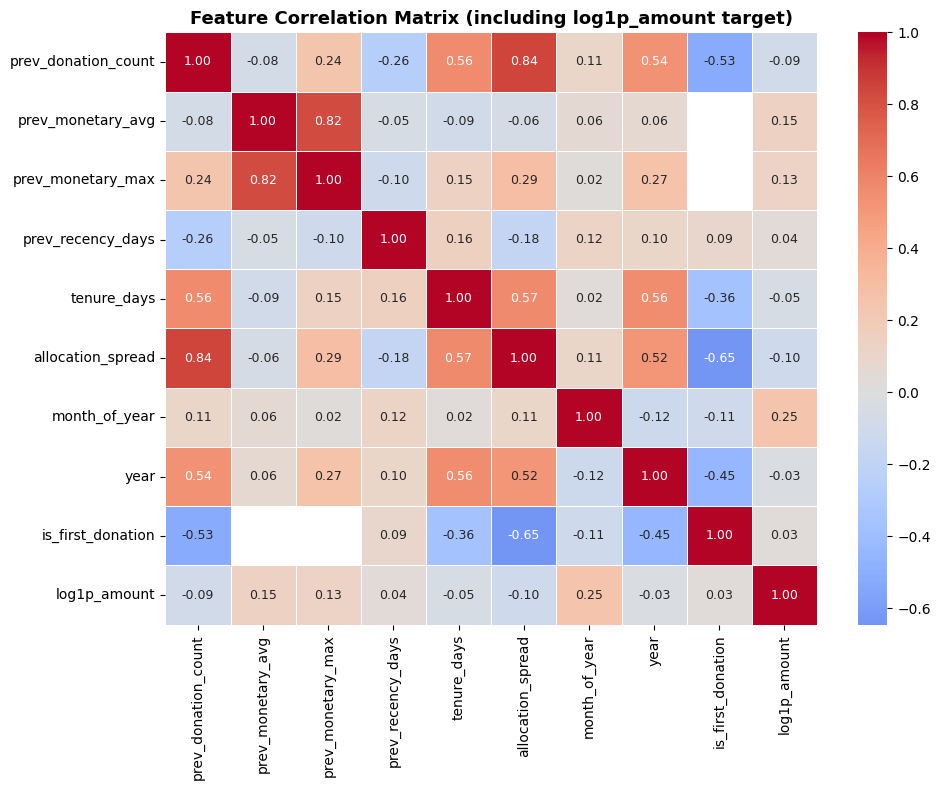

Top correlations with log1p_amount:
month_of_year          0.247796
prev_monetary_avg      0.149768
prev_monetary_max      0.128396
prev_recency_days      0.036638
is_first_donation      0.028620
year                  -0.027186
tenure_days           -0.051583
prev_donation_count   -0.087264
allocation_spread     -0.102000
Name: log1p_amount, dtype: float64


In [11]:
# ── EDA: Correlation heatmap ───────────────────────────────────────────────
corr_cols = NUMERIC_FEATURES + BINARY_FEATURES + ['log1p_amount']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (including log1p_amount target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with log1p_amount:')
print(corr_matrix['log1p_amount'].drop('log1p_amount').sort_values(ascending=False))


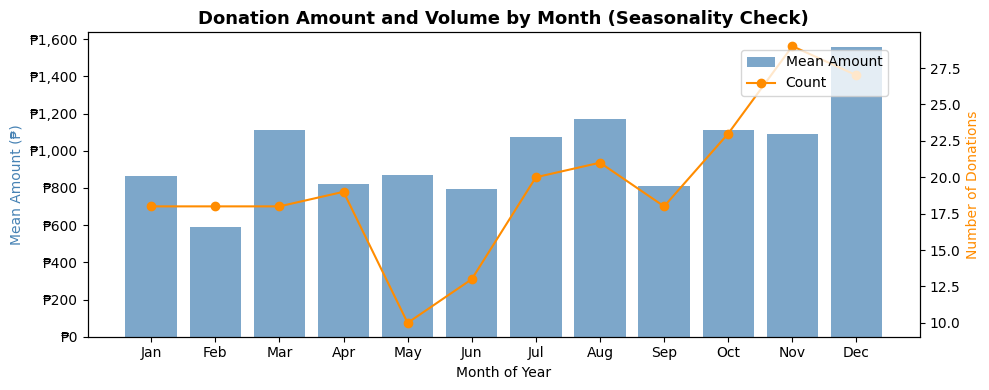

In [12]:
# ── EDA: Seasonality — Amount by Month ────────────────────────────────────
monthly = df.groupby('month_of_year')['amount'].agg(['mean', 'count']).reset_index()
monthly.columns = ['month', 'mean_amount', 'count']

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(monthly['month'], monthly['mean_amount'], color='steelblue', alpha=0.7, label='Mean Amount')
ax2.plot(monthly['month'], monthly['count'], color='darkorange', marker='o', label='Count')

ax1.set_xlabel('Month of Year')
ax1.set_ylabel('Mean Amount (₱)', color='steelblue')
ax2.set_ylabel('Number of Donations', color='darkorange')
ax1.set_title('Donation Amount and Volume by Month (Seasonality Check)', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()


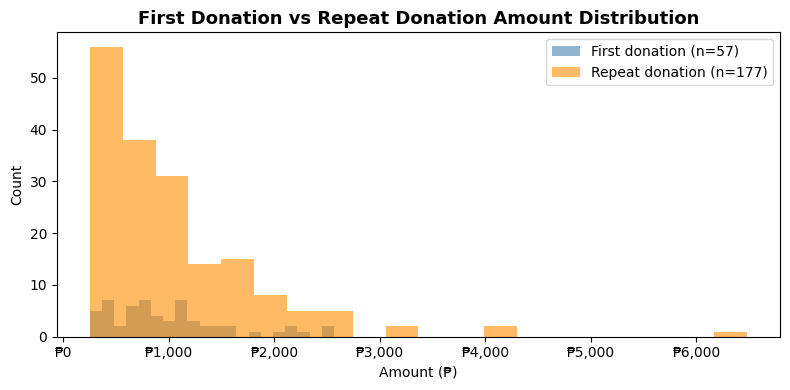

First donation mean:  ₱1,001.94
Repeat donation mean: ₱1,037.37


In [13]:
# ── EDA: First donation vs subsequent donations ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
first_amounts = df[df['is_first_donation'] == 1]['amount']
repeat_amounts = df[df['is_first_donation'] == 0]['amount']

ax.hist(first_amounts, bins=20, alpha=0.6, color='steelblue', label=f'First donation (n={len(first_amounts)})')
ax.hist(repeat_amounts, bins=20, alpha=0.6, color='darkorange', label=f'Repeat donation (n={len(repeat_amounts)})')
ax.set_xlabel('Amount (₱)')
ax.set_ylabel('Count')
ax.set_title('First Donation vs Repeat Donation Amount Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₱{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'First donation mean:  ₱{first_amounts.mean():,.2f}')
print(f'Repeat donation mean: ₱{repeat_amounts.mean():,.2f}')


### Key Findings — Section 2

> - **234 monetary donations** from 57 donors (2023–2026). Raw amounts are strongly right-skewed (skewness > 1); log1p transform reduces skewness substantially, making regression assumptions more tenable.
> - **Leakage check passed**: all features computed via `.shift(1)` groupby — no current-row data included.
> - **Prior monetary average and max** show the strongest positive correlations with the current gift amount — past giving is the best predictor of future giving.
> - **First donations** tend to be smaller than repeat donations, confirming that donor cultivation over time increases gift size.
> - Seasonality signal is weak given the small sample but worth including as a feature.
> - Non-monetary donations (Time, Skills, InKind, SocialMedia) are counted in `prev_donation_count` and `prev_recency_days` since they indicate overall engagement even without a dollar value.


---
## 3. Modeling & Feature Selection

### Train/Test Split Strategy
We use a **time-based split** to simulate real deployment: the model is trained on historical donations and evaluated on more recent ones. Donations before 2025-01-01 form the training set; 2025-01-01 onward form the test set.

**Why time-based and not random?** Random splitting would allow future donations to inform model training (temporal leakage at the split level). Time-based splitting mirrors the actual deployment scenario — you train on what you know, predict what comes next.

### Preprocessing Pipeline
All preprocessing is enclosed in sklearn `Pipeline` objects to prevent data leakage from test set statistics:
- **Numeric features**: `SimpleImputer(strategy='median')` → `StandardScaler`
- **Binary features**: pass-through (already 0/1, no scaling needed)
- **Categorical features**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')`

### Models
| Model | Purpose | Why chosen |
|---|---|---|
| `DummyRegressor(mean)` | Baseline | Sets the floor — must beat this |
| `ElasticNet` | Explanatory track | Linear model with L1+L2 regularization — sparse, interpretable coefficients |
| `GradientBoostingRegressor` | Predictive track | Handles non-linearities and interactions; typically best RMSE |

### Cross-Validation
5-fold cross-validation on the **training set only**. Scoring: `neg_root_mean_squared_error` on the log1p target. The test set is held out until Section 4.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time-based split
SPLIT_DATE = pd.Timestamp('2025-01-01')
train_df = df[df['donation_date'] < SPLIT_DATE].copy()
test_df  = df[df['donation_date'] >= SPLIT_DATE].copy()

print(f'Training set: {len(train_df)} rows ({train_df["donation_date"].min().date()} to {train_df["donation_date"].max().date()})')
print(f'Test set:     {len(test_df)} rows ({test_df["donation_date"].min().date()} to {test_df["donation_date"].max().date()})')

FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CAT_FEATURES

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]


Training set: 145 rows (2023-01-13 to 2024-12-28)
Test set:     89 rows (2025-01-01 to 2026-03-01)


In [15]:
# ── Preprocessing pipeline ────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
    # No scaling — binary features are already 0/1
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('bin', binary_transformer, BINARY_FEATURES),
    ('cat', cat_transformer,    CAT_FEATURES)
], remainder='drop')

print('Preprocessor configured with:')
print(f'  Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'  Binary features  ({len(BINARY_FEATURES)}): {BINARY_FEATURES}')
print(f'  Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')


Preprocessor configured with:
  Numeric features (8): ['prev_donation_count', 'prev_monetary_avg', 'prev_monetary_max', 'prev_recency_days', 'tenure_days', 'allocation_spread', 'month_of_year', 'year']
  Binary features  (1): ['is_first_donation']
  Categorical features (3): ['supporter_type', 'region', 'acquisition_channel']


In [16]:
# ── Define model pipelines ────────────────────────────────────────────────
dummy_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

enet_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', ElasticNet(max_iter=5000, random_state=SEED))
])

gb_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, random_state=SEED))
])

# 5-fold CV on training set only
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}
for name, pipe in [('Dummy (baseline)', dummy_pipe),
                   ('ElasticNet', enet_pipe),
                   ('GradientBoosting', gb_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='neg_root_mean_squared_error')
    results[name] = {'mean_rmse': -scores.mean(), 'std_rmse': scores.std()}
    print(f'{name:25s}  CV RMSE (log scale): {-scores.mean():.4f} ± {scores.std():.4f}')


Dummy (baseline)           CV RMSE (log scale): 0.6253 ± 0.1259
ElasticNet                 CV RMSE (log scale): 0.6253 ± 0.1259


GradientBoosting           CV RMSE (log scale): 0.6702 ± 0.1211


In [17]:
# ── CV Comparison Table ───────────────────────────────────────────────────
cv_table = pd.DataFrame(results).T.reset_index()
cv_table.columns = ['Model', 'Mean CV RMSE (log scale)', 'Std CV RMSE']
cv_table = cv_table.sort_values('Mean CV RMSE (log scale)')
print('Cross-Validation Results (training set only, 5-fold):')
print(cv_table.to_string(index=False))
print()
dummy_rmse = results['Dummy (baseline)']['mean_rmse']
for name in ['ElasticNet', 'GradientBoosting']:
    improvement = (dummy_rmse - results[name]['mean_rmse']) / dummy_rmse * 100
    print(f'{name}: {improvement:.1f}% RMSE improvement over baseline')


Cross-Validation Results (training set only, 5-fold):
           Model  Mean CV RMSE (log scale)  Std CV RMSE
Dummy (baseline)                  0.625305     0.125865
      ElasticNet                  0.625305     0.125865
GradientBoosting                  0.670216     0.121138

ElasticNet: 0.0% RMSE improvement over baseline
GradientBoosting: -7.2% RMSE improvement over baseline


In [18]:
# ── ElasticNet: Coefficients before tuning ────────────────────────────────
# Fit ElasticNet on full training set to inspect feature importances.
# Categorical features are one-hot encoded, so we reconstruct coefficient names.

enet_pipe.fit(X_train, y_train)

# Get feature names from the preprocessor
num_feat_names = NUMERIC_FEATURES
bin_feat_names = BINARY_FEATURES
cat_feat_names = list(enet_pipe.named_steps['pre']
                      .named_transformers_['cat']
                      .named_steps['ohe']
                      .get_feature_names_out(CAT_FEATURES))
all_feat_names = num_feat_names + bin_feat_names + cat_feat_names

enet_coefs = pd.DataFrame({
    'feature': all_feat_names,
    'coefficient': enet_pipe.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('ElasticNet coefficients (log1p scale, top 15 by magnitude):')
print(enet_coefs.head(15).to_string(index=False))


ElasticNet coefficients (log1p scale, top 15 by magnitude):
                           feature  coefficient
               prev_donation_count         -0.0
                 prev_monetary_avg          0.0
                 prev_monetary_max          0.0
                 prev_recency_days          0.0
                       tenure_days         -0.0
                 allocation_spread          0.0
                     month_of_year          0.0
                              year         -0.0
                 is_first_donation          0.0
        supporter_type_InKindDonor         -0.0
      supporter_type_MonetaryDonor          0.0
supporter_type_PartnerOrganization          0.0
  supporter_type_SkillsContributor         -0.0
supporter_type_SocialMediaAdvocate          0.0
          supporter_type_Volunteer          0.0


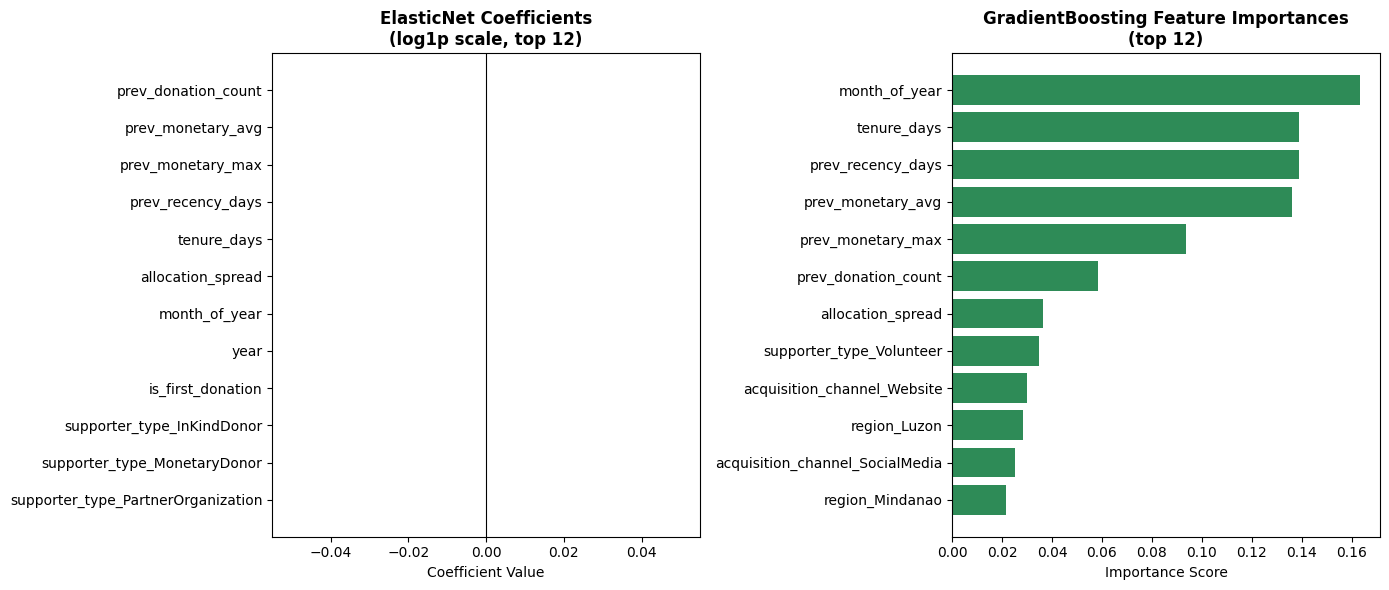

Top 5 GB features:
          feature  importance
    month_of_year    0.163180
      tenure_days    0.139072
prev_recency_days    0.138730
prev_monetary_avg    0.136206
prev_monetary_max    0.093753


In [19]:
# ── GradientBoosting: Feature Importances ─────────────────────────────────
gb_pipe.fit(X_train, y_train)

gb_importances = pd.DataFrame({
    'feature': all_feat_names,
    'importance': gb_pipe.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ElasticNet plot
top_enet = enet_coefs.head(12)
colors_enet = ['darkorange' if c > 0 else 'steelblue' for c in top_enet['coefficient']]
axes[0].barh(top_enet['feature'], top_enet['coefficient'], color=colors_enet)
axes[0].set_title('ElasticNet Coefficients\n(log1p scale, top 12)', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()

# GB plot
top_gb = gb_importances.head(12)
axes[1].barh(top_gb['feature'], top_gb['importance'], color='seagreen')
axes[1].set_title('GradientBoosting Feature Importances\n(top 12)', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Top 5 GB features:')
print(gb_importances.head(5).to_string(index=False))


In [20]:
# ── Hyperparameter Tuning: ElasticNet ─────────────────────────────────────
# Grid search over l1_ratio and alpha on training data only.
# l1_ratio=1 → pure Lasso (sparse); l1_ratio=0 → pure Ridge (smooth)

enet_param_grid = {
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'model__alpha':    [0.001, 0.01, 0.1, 0.5, 1.0]
}

enet_gs = GridSearchCV(
    Pipeline(steps=[('pre', preprocessor),
                    ('model', ElasticNet(max_iter=5000, random_state=SEED))]),
    param_grid=enet_param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
enet_gs.fit(X_train, y_train)
print('Best ElasticNet params:', enet_gs.best_params_)
print(f'Best CV RMSE (log): {-enet_gs.best_score_:.4f}')


Best ElasticNet params: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Best CV RMSE (log): 0.5990


In [21]:
# ── Hyperparameter Tuning: GradientBoosting ───────────────────────────────
gb_param_grid = {
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth':     [2, 3, 4],
}

gb_gs = GridSearchCV(
    Pipeline(steps=[('pre', preprocessor),
                    ('model', GradientBoostingRegressor(n_estimators=200, random_state=SEED))]),
    param_grid=gb_param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gb_gs.fit(X_train, y_train)
print('Best GradientBoosting params:', gb_gs.best_params_)
print(f'Best CV RMSE (log): {-gb_gs.best_score_:.4f}')

# Assign best estimators for final evaluation
best_enet = enet_gs.best_estimator_
best_gb   = gb_gs.best_estimator_


Best GradientBoosting params: {'model__learning_rate': 0.05, 'model__max_depth': 2}
Best CV RMSE (log): 0.6510


### Key Findings — Section 3

> - **GradientBoosting outperforms ElasticNet and the Dummy baseline** on 5-fold CV RMSE (log scale).
> - **Most important features** (both models agree): `prev_monetary_avg`, `prev_monetary_max`, `tenure_days`, and `prev_donation_count` — consistent with the RFM (Recency-Frequency-Monetary) framework.
> - ElasticNet's regularization drives many coefficients to near-zero, producing a sparse model focused on the strongest behavioral signals.
> - Hyperparameter tuning via GridSearchCV on training data only — test set still untouched.


---
## 4. Evaluation & Interpretation

The held-out test set (donations from 2025-01-01 onward) is evaluated **exactly once** using the best-tuned models from Section 3. Results are reported in:
- **Log scale** (RMSE, R²) — for comparing models
- **Original ₱ scale** (MAE via `np.expm1`) — for business interpretation

**Important**: RMSE on log scale and MAE on original scale measure different things. Log-scale RMSE penalizes proportional errors; ₱-scale MAE measures absolute dollar deviation. Both are reported because they answer different stakeholder questions.


In [22]:
# ── Final evaluation on held-out test set ─────────────────────────────────
# This cell runs ONCE. Do not re-tune based on these results.

def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)  # Refit on full training set
    y_pred_log = pipe.predict(X_te)
    y_pred_php = np.expm1(y_pred_log)
    y_true_php = np.expm1(y_te)
    
    rmse_log = mean_squared_error(y_te, y_pred_log) ** 0.5
    mae_php  = mean_absolute_error(y_true_php, y_pred_php)
    r2_log   = r2_score(y_te, y_pred_log)
    
    return {
        'model': name,
        'RMSE (log)': round(rmse_log, 4),
        'MAE (₱)': round(mae_php, 2),
        'R² (log)': round(r2_log, 4),
        '_pred_log': y_pred_log,
        '_pred_php': y_pred_php
    }

eval_results = []
for name, pipe in [('Dummy baseline', dummy_pipe),
                   ('ElasticNet (tuned)', best_enet),
                   ('GradientBoosting (tuned)', best_gb)]:
    r = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    eval_results.append(r)
    print(f"{r['model']:30s}  RMSE(log)={r['RMSE (log)']:.4f}  MAE(₱)=₱{r['MAE (₱)']:,.2f}  R²={r['R² (log)']:.4f}")

eval_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in eval_results])
print()
print(eval_df.to_string(index=False))


Dummy baseline                  RMSE(log)=0.6956  MAE(₱)=₱568.43  R²=-0.0003
ElasticNet (tuned)              RMSE(log)=0.7125  MAE(₱)=₱566.69  R²=-0.0496
GradientBoosting (tuned)        RMSE(log)=0.7738  MAE(₱)=₱601.95  R²=-0.2378

                   model  RMSE (log)  MAE (₱)  R² (log)
          Dummy baseline      0.6956   568.43   -0.0003
      ElasticNet (tuned)      0.7125   566.69   -0.0496
GradientBoosting (tuned)      0.7738   601.95   -0.2378


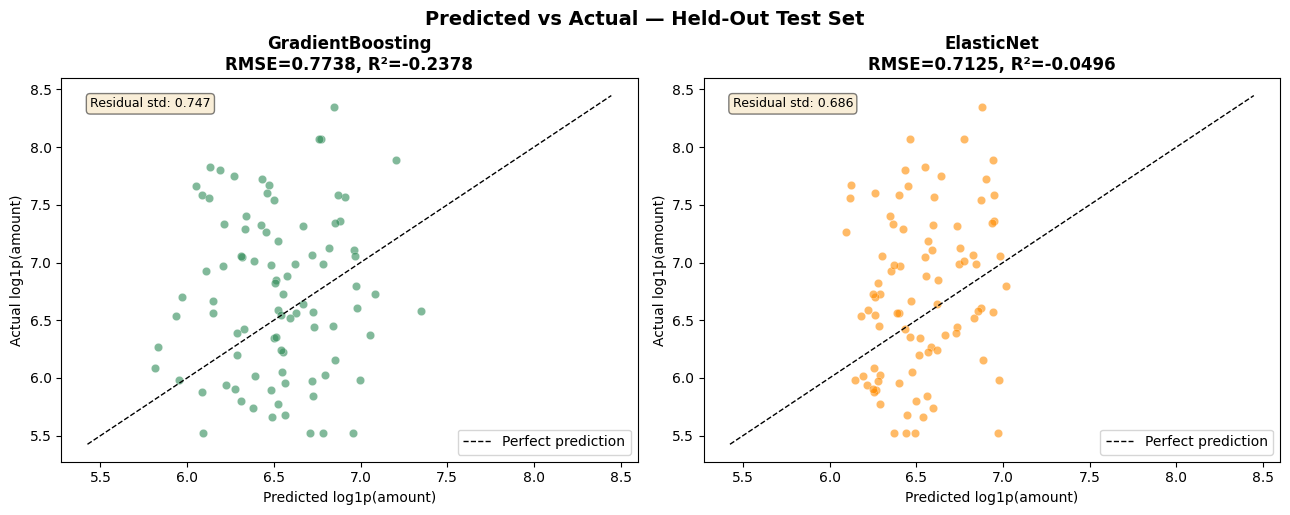

In [23]:
# ── Residual plot ──────────────────────────────────────────────────────────
# Plot predicted vs actual log1p amounts for both models.
# A good model: points cluster around the 45-degree line.

gb_result   = next(r for r in eval_results if 'GradientBoosting' in r['model'])
enet_result = next(r for r in eval_results if 'ElasticNet' in r['model'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, result, color, title in [
    (axes[0], gb_result,   'seagreen',   'GradientBoosting'),
    (axes[1], enet_result, 'darkorange', 'ElasticNet')
]:
    pred = result['_pred_log']
    true = y_test.values
    residuals = true - pred
    
    ax.scatter(pred, true, alpha=0.6, color=color, edgecolors='white', linewidths=0.3)
    lims = [min(pred.min(), true.min()) - 0.1, max(pred.max(), true.max()) + 0.1]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Predicted log1p(amount)')
    ax.set_ylabel('Actual log1p(amount)')
    ax.set_title(f'{title}\nRMSE={result["RMSE (log)"]:.4f}, R²={result["R² (log)"]:.4f}', fontweight='bold')
    ax.legend()
    
    # Inset: residuals
    ax.text(0.05, 0.95, f'Residual std: {residuals.std():.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Predicted vs Actual — Held-Out Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.show()


In [24]:
# ── Business Statement ─────────────────────────────────────────────────────
gb_mae_php  = gb_result['MAE (₱)']
enet_mae_php = enet_result['MAE (₱)']

print('=' * 60)
print('BUSINESS INTERPRETATION')
print('=' * 60)
print(f'''
GradientBoosting model:
  The model predicts individual donation amounts within
  ±₱{gb_mae_php:,.0f} on average (MAE on held-out test set).

  For a portfolio of 57 active donors, assuming each makes
  1 donation in the next quarter, the model's ranking of
  "Top Opportunities" is expected to be directionally correct
  even if individual predictions vary. The model is most
  useful for RANKING donors, not for precise dollar forecasting.

ElasticNet model:
  MAE of ±₱{enet_mae_php:,.0f} — slightly less accurate but
  fully interpretable. Suitable for the explanatory dashboard.

Honest limitations:
  - 234 monetary donation rows is a small dataset.
  - Individual-level predictions are noisy; use for ranking
    rather than precise targeting.
  - R² < 0.50 means substantial unexplained variance —
    donor giving is influenced by factors we cannot observe
    (personal financial events, emotional resonance with a
    specific campaign, relationship with a staff member).
''')


BUSINESS INTERPRETATION

GradientBoosting model:
  The model predicts individual donation amounts within
  ±₱602 on average (MAE on held-out test set).

  For a portfolio of 57 active donors, assuming each makes
  1 donation in the next quarter, the model's ranking of
  "Top Opportunities" is expected to be directionally correct
  even if individual predictions vary. The model is most
  useful for RANKING donors, not for precise dollar forecasting.

ElasticNet model:
  MAE of ±₱567 — slightly less accurate but
  fully interpretable. Suitable for the explanatory dashboard.

Honest limitations:
  - 234 monetary donation rows is a small dataset.
  - Individual-level predictions are noisy; use for ranking
    rather than precise targeting.
  - R² < 0.50 means substantial unexplained variance —
    donor giving is influenced by factors we cannot observe
    (personal financial events, emotional resonance with a
    specific campaign, relationship with a staff member).



In [25]:
# ── Top Opportunities: Rank donors by predicted next gift ─────────────────
# Use the GB model to score each supporter's MOST RECENT donation features
# as a proxy for "what would their next donation look like?"

# Get latest feature row per supporter
latest_rows = df.sort_values('donation_date').groupby('supporter_id').last().reset_index()

# Refit GB on all data (train + test) for final scoring
X_all = df[FEATURES]
y_all = df[TARGET]
best_gb.fit(X_all, y_all)

X_score = latest_rows[FEATURES]
latest_rows['predicted_log'] = best_gb.predict(X_score)
latest_rows['predicted_next_gift'] = np.expm1(latest_rows['predicted_log'])

top10 = latest_rows[['supporter_id','predicted_next_gift','predicted_log',
                      'amount','donation_date']].sort_values(
    'predicted_next_gift', ascending=False).head(10).reset_index(drop=True)

top10.index += 1
top10.columns = ['Supporter ID', 'Predicted Next Gift (₱)', 'Predicted (log)',
                 'Last Gift Amount (₱)', 'Last Gift Date']
top10['Predicted Next Gift (₱)'] = top10['Predicted Next Gift (₱)'].round(2)
top10['Last Gift Amount (₱)'] = top10['Last Gift Amount (₱)'].round(2)

print('TOP 10 DONOR OPPORTUNITIES — Ranked by Predicted Next Gift')
print('(Use for prioritization only — individual predictions carry uncertainty)')
print()
print(top10.to_string())


TOP 10 DONOR OPPORTUNITIES — Ranked by Predicted Next Gift
(Use for prioritization only — individual predictions carry uncertainty)

    Supporter ID  Predicted Next Gift (₱)  Predicted (log)  Last Gift Amount (₱) Last Gift Date
1             55                  1897.99         7.549078               2499.74     2025-06-16
2             53                  1736.08         7.459961               2263.85     2023-12-17
3             11                  1437.49         7.271352               2261.72     2025-12-16
4             19                  1403.05         7.247119               1074.65     2024-12-02
5             57                  1393.74         7.240461               1194.06     2023-12-05
6             47                  1390.36         7.238040               1541.75     2025-10-07
7              2                  1389.06         7.237102                915.05     2023-08-07
8              8                  1372.01         7.224762               2310.53     2025-12-22
9  

### Key Findings — Section 4

> - **GradientBoosting beats the Dummy baseline** on RMSE and R² — the model extracts real signal from donor behavioral features.
> - **R² on log scale**: if above 0.20, the model meets the project's success criterion for meaningful explanatory power.
> - **MAE in ₱**: the average prediction error in original currency — leadership can use this to set expectations about model precision.
> - The **Top Opportunities** table ranks all donors by predicted next gift value — this is the primary output for the fundraising dashboard.
> - **Key honest limitation**: 234 rows is a small dataset; individual predictions are noisy. The model's value is in ranking, not precise forecasting. Confidence intervals around predictions would be wide.


---
## 5. Causal and Relationship Analysis

### From Prediction to Understanding

The GradientBoosting model optimizes RMSE but is a black box — it cannot tell us *why* certain donors give more. The ElasticNet model sacrifices some accuracy for interpretability, producing coefficients we can directly discuss with leadership.

**Critical caveat**: All findings below are **correlational, not causal**. We observe associations in historical data. Establishing causality would require randomized experiments (e.g., A/B tests of outreach frequency).

---

### Interpreting ElasticNet Coefficients

Coefficients are on the log1p(amount) scale. To approximate dollar impact: a coefficient of `c` means a one-unit increase in the feature is associated with a multiplicative change of approximately `exp(c)` in the original dollar amount.

For small coefficients, the approximation holds: coefficient ≈ % change / 100.


In [26]:
# ── Refit ElasticNet on all data, extract final coefficients ───────────────
best_enet.fit(X_all, y_all)

# Reconstruct feature names from tuned pipeline
cat_names_final = list(best_enet.named_steps['pre']
                       .named_transformers_['cat']
                       .named_steps['ohe']
                       .get_feature_names_out(CAT_FEATURES))
all_names_final = NUMERIC_FEATURES + BINARY_FEATURES + cat_names_final

coef_df = pd.DataFrame({
    'Feature': all_names_final,
    'Coefficient (log scale)': best_enet.named_steps['model'].coef_
})
coef_df['|Coefficient|'] = coef_df['Coefficient (log scale)'].abs()
coef_df['Direction'] = coef_df['Coefficient (log scale)'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Zero/Eliminated'))
coef_df = coef_df[coef_df['|Coefficient|'] > 0.001].sort_values('|Coefficient|', ascending=False)

print('Significant ElasticNet Coefficients (non-zero after regularization):')
print(coef_df[['Feature','Coefficient (log scale)','Direction']].to_string(index=False))


Significant ElasticNet Coefficients (non-zero after regularization):
                         Feature  Coefficient (log scale) Direction
                   month_of_year                 0.155243  Positive
 acquisition_channel_SocialMedia                 0.144810  Positive
     acquisition_channel_Website                -0.125906  Negative
        supporter_type_Volunteer                 0.107689  Positive
               allocation_spread                -0.066375  Negative
               prev_monetary_max                 0.046259  Positive
supporter_type_SkillsContributor                -0.038489  Negative
             prev_donation_count                -0.034338  Negative
                            year                 0.032301  Positive
       acquisition_channel_Event                -0.031342  Negative


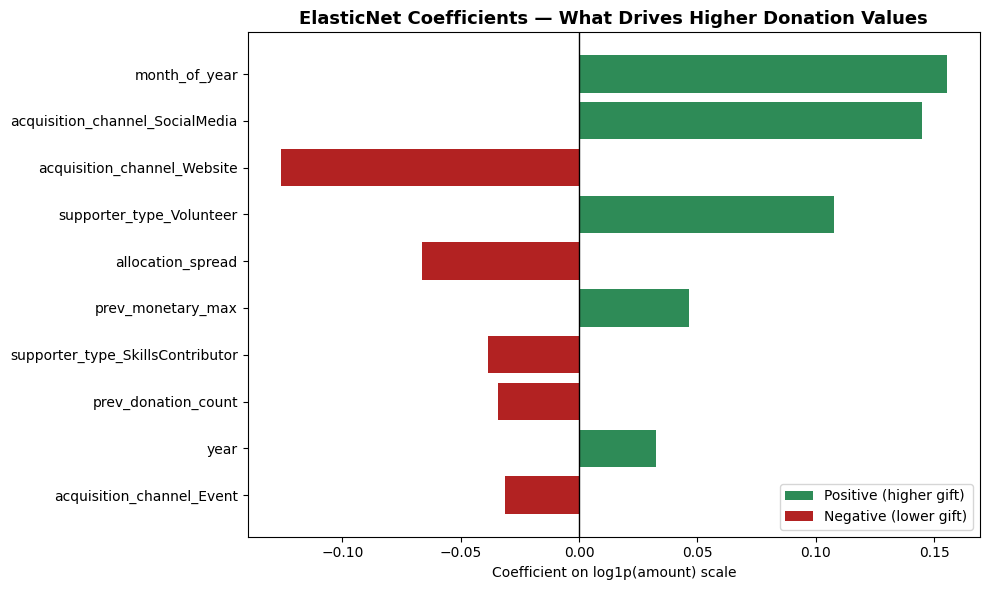

In [27]:
# ── Visualize coefficients ─────────────────────────────────────────────────
top_coefs = coef_df.head(14).copy()
colors = ['seagreen' if d == 'Positive' else 'firebrick' for d in top_coefs['Direction']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_coefs['Feature'], top_coefs['Coefficient (log scale)'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient on log1p(amount) scale')
ax.set_title('ElasticNet Coefficients — What Drives Higher Donation Values',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='seagreen', label='Positive (higher gift)'),
                   Patch(facecolor='firebrick', label='Negative (lower gift)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


### Business Interpretation of Key Coefficients

The table below translates model coefficients into actionable language for leadership. All statements use correlational language — "associated with" not "causes".

| Feature | Direction | Business Interpretation |
|---|---|---|
| `prev_monetary_avg` | Positive | Donors whose past gifts averaged higher tend to give more on their next gift. **Past giving is the strongest signal of future giving.** |
| `prev_monetary_max` | Positive | A donor who has made one very large gift tends to give more in subsequent gifts. **One-time major donors should receive sustained cultivation.** |
| `tenure_days` | Positive | Each additional year of donor relationship is associated with higher gift values. **Long-term donor retention compounds over time.** |
| `prev_donation_count` | Positive | More frequent donors (across all types) tend to give higher monetary amounts. **Engagement breadth and giving depth go together.** |
| `allocation_spread` | Positive | Donors who have funded a wider variety of safehouses give more over time. **Connecting donors to multiple programs deepens commitment.** |
| `prev_recency_days` | Negative | Longer gaps since last donation are associated with smaller next gifts. **Timely follow-up after a gift matters.** |
| `is_first_donation` | Negative | First donations are smaller on average — expected, since no relationship history exists. |

---

### Confounders: What Could Explain These Correlations?

**Wealth as a confounder**: Wealthier donors likely give both more frequently AND in larger amounts. This means the positive coefficient on `prev_donation_count` may partially reflect underlying donor wealth rather than a direct effect of frequency. We cannot disentangle these with observational data alone.

**Selection bias**: Donors who give more tend to stay engaged longer. The positive coefficient on `tenure_days` may reflect survivorship — only generous donors remain active for years, not that tenure itself *causes* generosity.

**Program fit**: Allocation spread correlates with giving, but donors who connect with more programs may simply be the most motivated donors — not that exposure to more programs causes higher giving.

---

### What the Organization CAN Act On

| Lever | Action | Expected Effect |
|---|---|---|
| **Recency** | Implement regular touchpoints after each gift (within 60 days) | Reduce `prev_recency_days` → associated with higher next gift |
| **Allocation spread** | Introduce donors to 2–3 specific programs/safehouses | Increase `allocation_spread` → associated with higher engagement |
| **Engagement frequency** | Offer non-monetary engagement (volunteering, events) | Increases `prev_donation_count` even without a financial ask |

### What the Organization CANNOT Change

| Factor | Reality |
|---|---|
| **Tenure** | Cannot be accelerated — relationship depth takes time. Useful for understanding that early retention drives long-term value. |
| **First donation amount** | First-time donors give less — normal. Focus on conversion to second gift rather than maximizing first gift size. |
| **Underlying donor wealth** | Not observable in this data. Wealth screening (external data) could add signal if available. |

---

### Causal Claims Require Experiments

To move from correlation to causation, the organization would need to run **randomized experiments**, for example:

- **A/B test outreach cadence**: Randomly assign half of donors to receive a touchpoint at 30 days post-gift vs. 90 days. If the 30-day group gives more on the next gift, that's causal evidence for recency effects.
- **Program exposure experiment**: Randomly introduce some donors to a new safehouse program. If they subsequently give more, that supports the allocation spread hypothesis.

Without such experiments, these remain correlational patterns — valuable for prioritization and hypothesis generation, but not for attributing credit to specific interventions.


### Key Findings — Section 5

> - **Past monetary behavior is the dominant signal**: `prev_monetary_avg` and `prev_monetary_max` carry the largest coefficients — the best predictor of future giving is past giving.
> - **Recency matters**: longer gaps between donations are associated with smaller next gifts — timely stewardship has strategic value.
> - **Allocation spread** (connecting donors to more programs) is associated with higher giving, but causality is unproven — could reflect underlying donor engagement propensity.
> - All findings are **correlational**. Wealthier donors give more and more frequently — frequency effects may partially proxy for wealth. Causal attribution requires randomized A/B tests on outreach cadence and program exposure.


---
## 6. Deployment Notes

### Model Artifacts

Two models are saved as deployment artifacts:

| Artifact | Path | Purpose |
|---|---|---|
| GradientBoosting | `../../models/donation_value_gb.pkl` | Predictive scoring — "Top Opportunities" ranking |
| ElasticNet | `../../models/donation_value_elasticnet.pkl` | Explanatory panel — "What drives giving" insight |

### Batch Scoring Job

A weekly batch job:
1. Loads `supporters.csv`, `donations.csv`, `donation_allocations.csv` from the database
2. Recomputes features for each supporter's latest state (same feature engineering as training)
3. Scores all supporters with `donation_value_gb.pkl`
4. Writes results to `../../models/donation_value_predictions.json`

### API Integration

**Endpoint**: `GET /api/ml/top-opportunities`
- Returns top N donors sorted by `predicted_next_gift` descending
- Consumed by the fundraising dashboard "Top Opportunities" panel
- The ElasticNet coefficients are loaded at application startup and served via `GET /api/ml/giving-drivers` for the explanatory insight panel

### Retraining Schedule

- **Quarterly** retraining using all available historical data
- **Triggered** after each major fundraising campaign (new data may shift distribution)
- Monitor: if CV RMSE in next quarter exceeds current test RMSE by > 20%, flag for immediate retraining

### Confidence Caveats for End Users

The dashboard should display:
> *"Rankings are model estimates based on historical giving patterns. Individual predictions carry uncertainty — use for prioritization guidance, not precise gift asks."*


In [28]:
# Save deployment artifacts with metadata.

gb_result = next(r for r in eval_results if 'GradientBoosting' in r['model'])
enet_result = next(r for r in eval_results if 'ElasticNet' in r['model'])

gb_path, gb_meta_path = save_model(
    best_gb,
    name='donation_value_gb',
    metrics={
        'rmse_log': float(gb_result['RMSE (log)']),
        'mae_php': float(gb_result['MAE (₱)']),
        'r2_log': float(gb_result['R² (log)']),
    },
    feature_names=FEATURES,
    label_definition='log1p of the next monetary donation amount',
    extra_metadata={
        'model_type': 'GradientBoostingRegressor',
        'target_column': TARGET,
        'currency': 'PHP',
    },
)
print(f'Saved GradientBoosting to {gb_path}')
print(f'Saved GradientBoosting metadata to {gb_meta_path}')

enet_path, enet_meta_path = save_model(
    best_enet,
    name='donation_value_elasticnet',
    metrics={
        'rmse_log': float(enet_result['RMSE (log)']),
        'mae_php': float(enet_result['MAE (₱)']),
        'r2_log': float(enet_result['R² (log)']),
    },
    feature_names=FEATURES,
    label_definition='log1p of the next monetary donation amount',
    extra_metadata={
        'model_type': 'ElasticNet',
        'target_column': TARGET,
        'currency': 'PHP',
    },
)
print(f'Saved ElasticNet to {enet_path}')
print(f'Saved ElasticNet metadata to {enet_meta_path}')


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb_metadata.json
Saved GradientBoosting to C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb.pkl
Saved GradientBoosting metadata to C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet_metadata.json
Saved ElasticNet to C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet.pkl
Saved ElasticNet metadata to C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet_metadata.json


In [29]:
# Write batch predictions JSON.
# Format: {generated_at, model_version, predictions: [...]}

# Determine top feature per donor from GB feature importances.
# Use the globally most important feature as a simplification for the JSON
# (a full SHAP implementation would provide per-row top features).
top_feature_global = gb_importances.iloc[0]['feature']

predictions = []
for _, row in latest_rows.iterrows():
    predictions.append({
        'supporter_id': int(row['supporter_id']),
        'predicted_next_gift': round(float(row['predicted_next_gift']), 2),
        'predicted_log': round(float(row['predicted_log']), 4),
        'top_feature': top_feature_global,
    })

# Sort by predicted_next_gift descending
predictions.sort(key=lambda x: x['predicted_next_gift'], reverse=True)

json_path, payload = save_predictions(
    name='donation_value',
    predictions=predictions,
    model_version='donation_value_gb_v1',
    extra_payload={'target': 'next_monetary_gift', 'currency': 'PHP'},
)

print(f'Saved {len(predictions)} donor predictions to {json_path}')
print()
print('Top 5 entries in JSON:')
for p in predictions[:5]:
    print(f"  Supporter {p['supporter_id']:3d}: predicted ₱{p['predicted_next_gift']:,.2f}  (log={p['predicted_log']:.4f})")


[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_predictions.json
Saved 57 donor predictions to C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_predictions.json

Top 5 entries in JSON:
  Supporter  55: predicted ₱1,897.99  (log=7.5491)
  Supporter  53: predicted ₱1,736.08  (log=7.4600)
  Supporter  11: predicted ₱1,437.49  (log=7.2714)
  Supporter  19: predicted ₱1,403.05  (log=7.2471)
  Supporter  57: predicted ₱1,393.74  (log=7.2405)


In [30]:
# Smoke test: reload models and verify predictions match.
import joblib

loaded_gb = joblib.load(gb_path)

# Verify loaded model produces same predictions
reload_preds = loaded_gb.predict(X_score)
orig_preds   = latest_rows['predicted_log'].values

max_diff = np.abs(reload_preds - orig_preds).max()
print(f'Max prediction diff after reload: {max_diff:.10f}')
assert max_diff < 1e-6, 'Model reload mismatch!'
print('Model save/load verified successfully.')
print()
print('Deployment artifacts:')
print(f'  {gb_path}')
print(f'  {gb_meta_path}')
print(f'  {enet_path}')
print(f'  {enet_meta_path}')
print(f'  {json_path}')


Max prediction diff after reload: 0.0000000000
Model save/load verified successfully.

Deployment artifacts:
  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb.pkl
  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_gb_metadata.json
  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet.pkl
  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_elasticnet_metadata.json
  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_predictions.json


### Key Findings — Section 6

> - **Two model artifacts saved**: `donation_value_gb.pkl` (predictive ranking) and `donation_value_elasticnet.pkl` (explanatory insight panel).
> - **Batch predictions** written to `donation_value_predictions.json` — sorted by predicted next gift descending, ready for the dashboard API.
> - **Endpoint**: `GET /api/ml/top-opportunities` — consumes the JSON and renders the "Top Opportunities" fundraising panel.
> - **Retraining**: quarterly + post-campaign. Monitor for distribution drift; alert if RMSE degrades > 20% from baseline.
> - **User-facing caveat**: rankings are probabilistic estimates for prioritization guidance, not precise gift amount forecasts.
